**<font color=skyblue>主成分分析（PCA）實作練習</font>**

- 透過知名資料集練習主成分分析（PCA）的原理與應用。
- 了解 PCA 如何將高維資料投影到較低維的空間，同時保留資料的主要變異性。
- 練習 PCA 的完整流程：資料探索 → 標準化 → PCA → 結果詮釋。

參考講義：https://ntpuccw.blog/python-in-learning/sml-lesson-5-%e4%b8%bb%e6%88%90%e5%88%86%e5%88%86%e6%9e%90%e7%9a%84%e5%8e%9f%e7%90%86%e8%88%87%e5%af%a6%e9%a9%97/

<hr>
<font color=yellow>範例 1</font>

RandMcNally Places Rated Almanac 提供了一組美國城市生活品質的調查資料，含 329 個城市的 9 個評量項目的分數。
我們嘗試用 PCA 從這些數字裡看到什麼訊息。

Data: `data/city_quality.xlsx`

<hr>

### Step 1：讀取資料

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.ticker import PercentFormatter

df = pd.read_excel('data/city_quality.xlsx')
print('資料形狀：', df.shape)
df.head()

資料形狀： (329, 9)


,climate,housing,health,crime,transportation,education,arts,recreation,economics
0,521,6200,237,923,4031,2757,996,1405,7633
1,575,8138,1656,886,4883,2438,5564,2632,4350
2,468,7339,618,970,2531,2560,237,859,5250
3,476,7908,1431,610,6883,3399,4655,1617,5864
4,659,8393,1853,1483,6558,3026,4496,2612,5727


In [2]:
# 查看基本統計量
df.describe()

,climate,housing,health,crime,transportation,education,arts,recreation,economics
count,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000
mean,538.732523,8346.559271,1185.738602,961.054711,4210.082067,2814.887538,3150.884498,1845.957447,5525.364742
std,120.808259,2385.262622,1003.002036,357.154186,1451.179240,320.792953,4642.283738,807.888171,1084.468523
min,105.000000,5159.000000,43.000000,308.000000,1145.000000,1701.000000,52.000000,300.000000,3045.000000
25%,480.000000,6760.000000,583.000000,707.000000,3141.000000,2619.000000,778.000000,1316.000000,4842.000000
50%,542.000000,7877.000000,833.000000,947.000000,4080.000000,2794.000000,1871.000000,1670.000000,5384.000000
75%,592.000000,9015.000000,1445.000000,1156.000000,5205.000000,3012.000000,3844.000000,2176.000000,6113.000000
max,910.000000,23640.000000,7850.000000,2498.000000,8625.000000,3781.000000,56745.000000,4800.000000,9980.000000


### Step 2：繪製盒鬚圖（原始資料）

觀察各評比項目的分布情況。

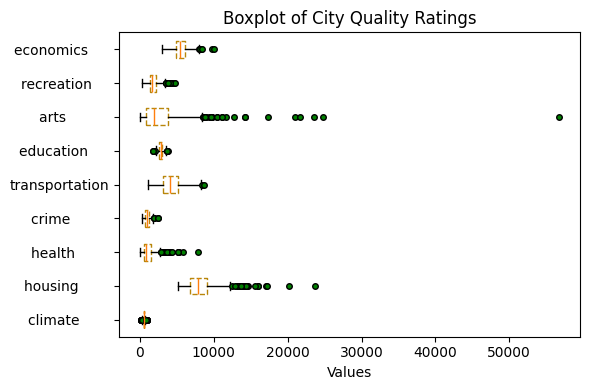

In [3]:
ratings = np.array(df)
categories = df.columns

fig, ax = plt.subplots(figsize=(6, 4))
boxprops = dict(linestyle='--', linewidth=1, color='darkgoldenrod')
flierprops = dict(marker='o', markerfacecolor='green', markersize=4, linestyle='none')

ax.boxplot(ratings, boxprops=boxprops, flierprops=flierprops,
           tick_labels=categories, vert=False)
ax.set_xlabel('Values')
ax.set_title('Boxplot of City Quality Ratings')
plt.tight_layout()
plt.show()

### Step 3：標準化資料

**思考問題：**
- 資料需要標準化的理由是什麼？
- 若不標準化，進行 PCA 會發生什麼問題？
- 標準化的數學公式為何？

> **回答：** （請填入你的答案）

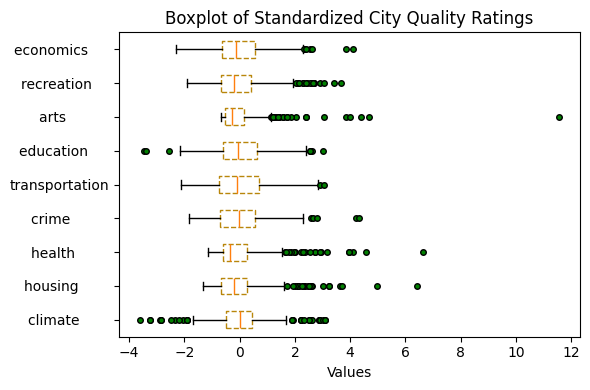

In [4]:
scaler = StandardScaler()
scaler.fit(ratings)
ratings_ = scaler.transform(ratings)

fig, ax = plt.subplots(figsize=(6, 4))
boxprops = dict(linestyle='--', linewidth=1, color='darkgoldenrod')
flierprops = dict(marker='o', markerfacecolor='green', markersize=4, linestyle='none')

ax.boxplot(ratings_, boxprops=boxprops, flierprops=flierprops,
           tick_labels=categories, vert=False)
ax.set_xlabel('Values')
ax.set_title('Boxplot of Standardized City Quality Ratings')
plt.tight_layout()
plt.show()

### Step 4：繪製相關性矩陣圖

**思考問題：**
- 相關性矩陣圖有什麼用途？
- 它與主成分分析有何關係？

> **回答：** （請填入你的答案）

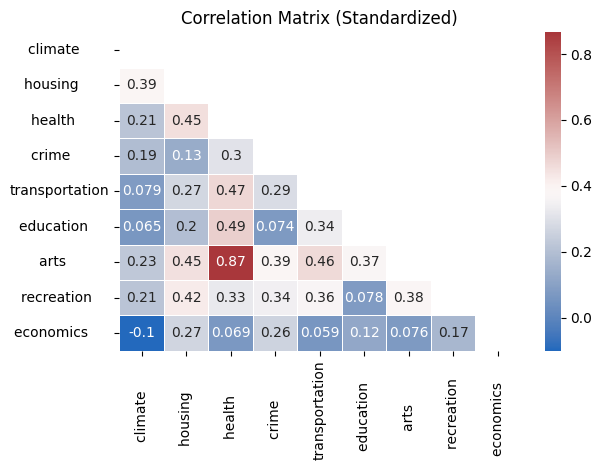

In [5]:
df_std = pd.DataFrame(ratings_, columns=categories)
R = df_std.corr()
mask = np.triu(np.ones_like(R, dtype=bool))
seaborn.heatmap(R, annot=True, mask=mask, cmap='vlag', linewidths=0.5)
plt.title('Correlation Matrix (Standardized)')
plt.tight_layout()
plt.show()

### Step 5：執行 PCA 並繪製 Scree Plot

**目標：** 確定應保留幾個主成分才能充分解釋資料的變異。

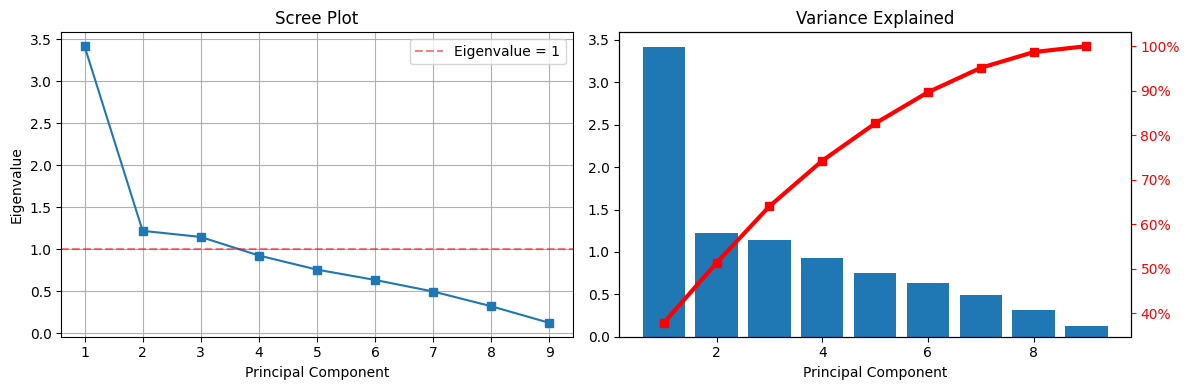

各主成分解釋變異比例： [0.3787 0.1349 0.1268 0.1023 0.0837 0.0701 0.0548 0.0353 0.0134]
前兩個主成分累積解釋變異： 0.5136


In [6]:
pca = PCA().fit(ratings_)

eigvals = pca.explained_variance_
eigvecs = pca.components_.T  # 特徵向量，按列排列

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(1, 1 + len(eigvals))

# Scree plot
ax[0].plot(x, eigvals, marker='s')
ax[0].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Eigenvalue = 1')
ax[0].set_title('Scree Plot')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Eigenvalue')
ax[0].legend()
ax[0].grid(True)

# Cumulative explained variance
ax[1].bar(x, eigvals)
ax2 = ax[1].twinx()
ax2.plot(x, pca.explained_variance_ratio_.cumsum() * 100,
         marker='s', color='red', lw=3)
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax[1].set_xlabel('Principal Component')
ax[1].set_title('Variance Explained')
plt.tight_layout()
plt.show()

print('各主成分解釋變異比例：', pca.explained_variance_ratio_.round(4))
print('前兩個主成分累積解釋變異：', pca.explained_variance_ratio_[:2].sum().round(4))

### Step 6：觀察前兩個主成分的散佈圖

**驗證理論性質：**
- 主成分之間的獨立性（相關係數應接近 0）
- 原變數的變異數總和 = 主成分的變異數總和（能量守恆）

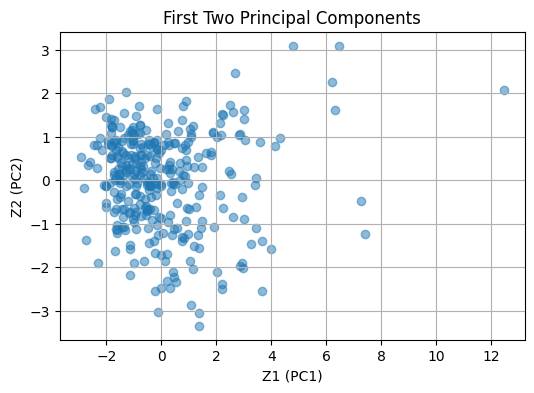

特徵值總和（主成分變異數和）： 9.0274
原始變數變異數和： 9.0274


In [7]:
Z = pca.transform(ratings_)

plt.figure(figsize=(6, 4))
plt.scatter(Z[:, 0], Z[:, 1], alpha=0.5)
plt.xlabel('Z1 (PC1)')
plt.ylabel('Z2 (PC2)')
plt.title('First Two Principal Components')
plt.grid(True)
plt.show()

# 驗證能量守恆
print('特徵值總和（主成分變異數和）：', eigvals.sum().round(4))
print('原始變數變異數和：', np.diag(np.cov(ratings_.T)).sum().round(4))

### Step 7：主成分負荷量（Loadings）分析

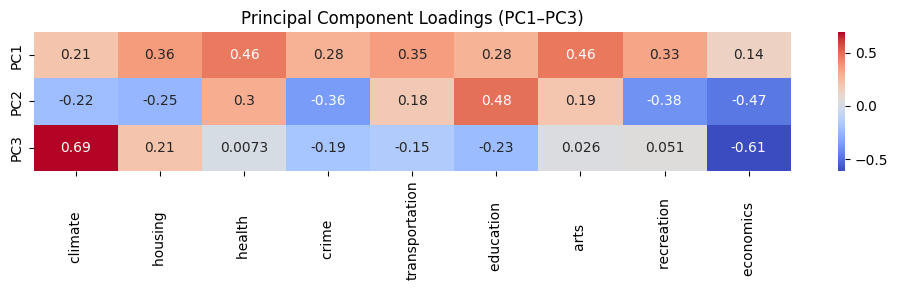

In [8]:
plt.figure(figsize=(10, 3))
seaborn.heatmap(pca.components_[:3, :], cmap='coolwarm', annot=True,
                xticklabels=categories,
                yticklabels=[f'PC{i}' for i in range(1, 4)])
plt.title('Principal Component Loadings (PC1–PC3)')
plt.tight_layout()
plt.show()

<font color=orange>**結論（範例 1）：**</font>

> （請根據上方圖表填入你的分析結論）
>
> - 應保留幾個主成分？理由為何？
> - 第一主成分代表什麼含義？
> - 哪些城市評比項目之間相關性較高？

<hr>
<font color=yellow>範例 2</font>

G. P. Frets 在 1921 年主持一項關於「男人頭顱形狀遺傳」的研究，蒐集了 25 個家庭的長子與次子的 head length（X1, Y1）與 head breadth（X2, Y2）。

研究目的：
- 頭型特徵是否具有遺傳性？
- 兄弟之間的頭顱尺寸是否相似？
- 家庭內部的頭型相關性有多強？

Data: `data/son.txt`

<hr>

### Step 1：讀取並探索資料

In [9]:
D = np.loadtxt('data/son.txt', comments='%')
df_son = pd.DataFrame(D, columns=['X1', 'X2', 'Y1', 'Y2'])
print('資料形狀：', df_son.shape)
print('欄位說明：X1=長子頭長, X2=長子頭寬, Y1=次子頭長, Y2=次子頭寬')
df_son.describe()

資料形狀： (25, 4)
欄位說明：X1=長子頭長, X2=長子頭寬, Y1=次子頭長, Y2=次子頭寬


,X1,X2,Y1,Y2
count,25.00000,25.000000,25.000000,25.000000
mean,185.72000,151.120000,183.840000,149.240000
std,9.76183,7.372923,10.040252,6.709943
min,163.00000,137.000000,161.000000,130.000000
25%,179.00000,147.000000,178.000000,147.000000
50%,188.00000,151.000000,185.000000,149.000000
75%,192.00000,155.000000,189.000000,152.000000
max,208.00000,167.000000,201.000000,159.000000


### Step 2：相關性矩陣分析

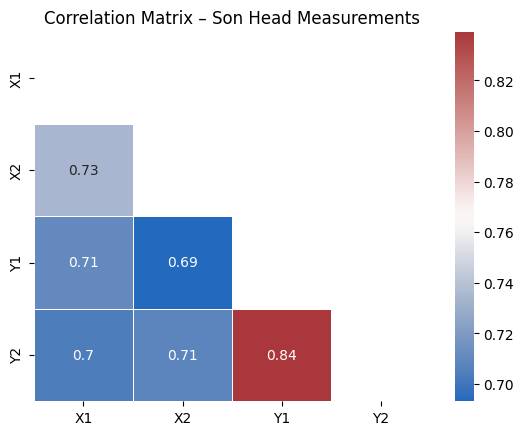

In [10]:
R_son = df_son.corr()
mask = np.triu(np.ones_like(R_son, dtype=bool))
seaborn.heatmap(R_son, annot=True, mask=mask, cmap='vlag', linewidths=0.5)
plt.title('Correlation Matrix – Son Head Measurements')
plt.show()

### Step 3：標準化 → PCA

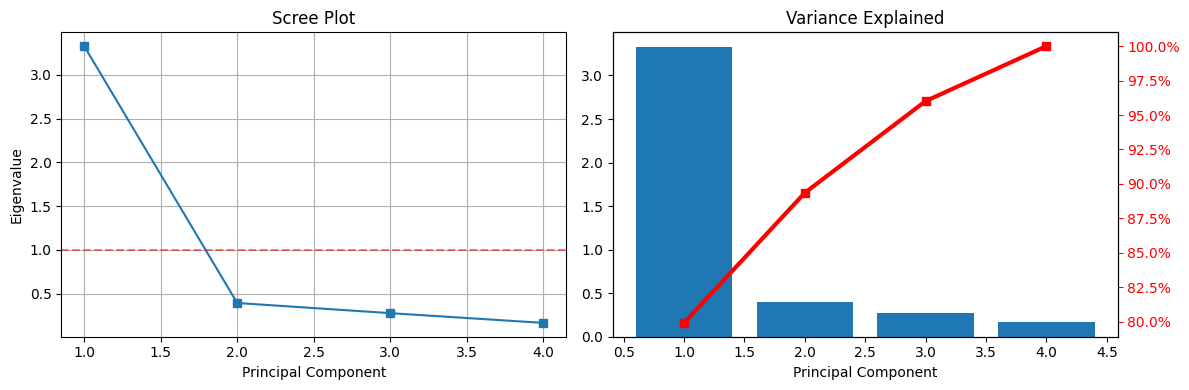

各主成分解釋變異比例： [0.799  0.0945 0.0666 0.0399]


In [11]:
scaler_son = StandardScaler()
df_son_scaled = scaler_son.fit_transform(df_son.values)

pca_son = PCA().fit(df_son_scaled)

eigvals_son = pca_son.explained_variance_

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(1, 1 + len(eigvals_son))

ax[0].plot(x, eigvals_son, marker='s')
ax[0].axhline(y=1, color='red', linestyle='--', alpha=0.5)
ax[0].set_title('Scree Plot')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Eigenvalue')
ax[0].grid(True)

ax[1].bar(x, eigvals_son)
ax2 = ax[1].twinx()
ax2.plot(x, pca_son.explained_variance_ratio_.cumsum() * 100,
         marker='s', color='red', lw=3)
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax[1].set_xlabel('Principal Component')
ax[1].set_title('Variance Explained')
plt.tight_layout()
plt.show()

print('各主成分解釋變異比例：', pca_son.explained_variance_ratio_.round(4))

### Step 4：主成分負荷量分析

觀察主成分的組合形式，詮釋其物理意義：
- **Z1 ≈ a(X1 + Y1 + X2 + Y2)**：代表整體頭顱大小
- **Z2 ≈ b(X1 - Y1 + X2 - Y2)**：代表頭型（長窄 vs 短寬）

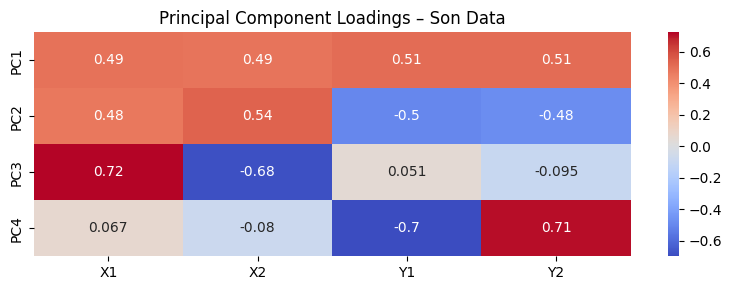

In [12]:
plt.figure(figsize=(8, 3))
seaborn.heatmap(pca_son.components_, cmap='coolwarm', annot=True,
                xticklabels=df_son.columns,
                yticklabels=[f'PC{i}' for i in range(1, 5)])
plt.title('Principal Component Loadings – Son Data')
plt.tight_layout()
plt.show()

### Step 5：前兩個主成分散佈圖

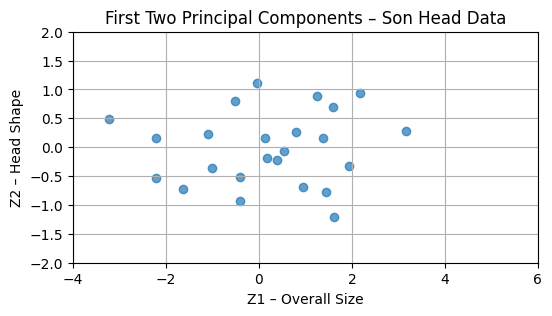

In [13]:
Z_son = pca_son.transform(df_son_scaled)[:, :2]

plt.figure(figsize=(6, 3))
plt.scatter(Z_son[:, 0], Z_son[:, 1], alpha=0.7)
plt.xlabel('Z1 – Overall Size')
plt.ylabel('Z2 – Head Shape')
plt.title('First Two Principal Components – Son Head Data')
plt.xlim(-4, 6)
plt.ylim(-2, 2)
plt.grid(True)
plt.show()

<font color=orange>**結論（範例 2）：**</font>

> （請根據上方圖表填入你的分析結論）
>
> - 前兩個主成分合計解釋多少百分比的變異？
> - Z1 和 Z2 分別代表什麼意義？
> - 從散佈圖中能看出什麼家庭遺傳模式？

<hr>
<font color=yellow>範例 3：自行練習</font>

一組「60 名美國大學 football 球員的六項頭圍數據」，來自一項頭部尺寸與美式足球安全性相關的研究。

六項量測數據：
- **WDIM**: head width at widest dimension（頭部最寬處）
- **CIRCUM**: head circumference（頭圍）
- **FBEYE**: front-to-back measurement at eye level（眼部水平前後長度）
- **EYEHD**: eye-to-top-of-head measurement（眼到頭頂距離）
- **EARHD**: ear-to-top-of-head measurement（耳到頭頂距離）
- **JAW**: jaw width（下顎寬度）

Data: `data/FOOTBALL.txt`

**請依照前述範例的步驟，完成以下分析：**
1. 讀取資料並探索基本統計量
2. 繪製盒鬚圖（原始 & 標準化）
3. 繪製相關性矩陣圖
4. 執行 PCA，繪製 Scree Plot 並決定保留幾個主成分
5. 繪製前兩個主成分的散佈圖
6. 分析主成分負荷量，詮釋各主成分的物理意義

<hr>

In [14]:
# Step 1：讀取資料
cols_fb = ['WDIM', 'CIRCUM', 'FBEYE', 'EYEHD', 'EARHD', 'JAW']

# 請在此處讀入 FOOTBALL.txt 並儲存為 df_fb
# df_fb = ...

In [15]:
# Step 2：繪製盒鬚圖


In [16]:
# Step 3：相關性矩陣圖


In [17]:
# Step 4：標準化 → PCA → Scree Plot


In [18]:
# Step 5：前兩個主成分散佈圖


In [19]:
# Step 6：主成分負荷量分析


<font color=orange>**結論（範例 3）：**</font>

> （請填入你的分析結論）

<hr>
<font color=yellow>範例 4：小麥種子資料集（Seeds Dataset）</font>

UCI Machine Learning Repository 的小麥種子資料集，包含 210 筆三種小麥品種（Kama、Rosa、Canadian）的 7 項幾何特徵量測。

七項特徵：
- Area（面積）
- Perimeter（周長）
- Compactness（緊密度）
- Length of kernel（粒長）
- Width of kernel（粒寬）
- Asymmetry coefficient（不對稱係數）
- Length of kernel groove（穀槽長度）

資料來源：https://archive.ics.uci.edu/dataset/236/seeds

<hr>

### Step 1：讀取資料

In [20]:
cols_seeds = ['area', 'perimeter', 'compactness', 'length', 'width', 'asymmetry', 'groove', 'class']
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
df_seeds = pd.read_csv(url, names=cols_seeds, sep=r'\s+')
print('資料形狀：', df_seeds.shape)
df_seeds.tail()

資料形狀： (210, 8)


,area,perimeter,compactness,length,width,asymmetry,groove,class
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3


In [21]:
# 分離特徵與類別標籤
labels_seeds = df_seeds.iloc[:, -1]
df_seeds_feat = df_seeds.iloc[:, :-1]
attributes_seeds = df_seeds_feat.columns

print('類別分布：')
print(labels_seeds.value_counts().sort_index())
print('\n1=Kama, 2=Rosa, 3=Canadian')

類別分布：
class
1    70
2    70
3    70
Name: count, dtype: int64

1=Kama, 2=Rosa, 3=Canadian


### Step 2：資料探索 — 盒鬚圖（原始 vs 標準化）

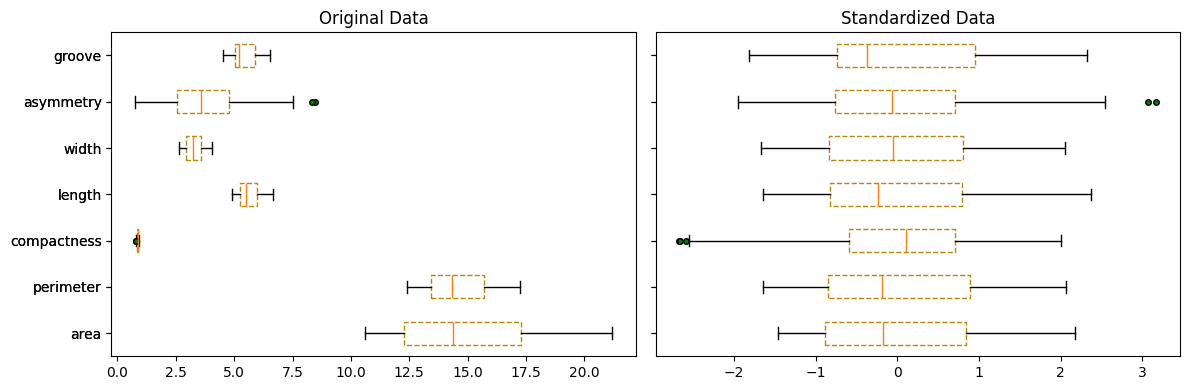

In [22]:
scaler_seeds = StandardScaler()
df_seeds_scaled = scaler_seeds.fit_transform(df_seeds_feat.values)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
boxprops = dict(linestyle='--', linewidth=1, color='darkgoldenrod')
flierprops = dict(marker='o', markerfacecolor='green', markersize=4, linestyle='none')

ax[0].boxplot(df_seeds_feat.values, boxprops=boxprops, flierprops=flierprops,
              tick_labels=attributes_seeds, vert=False)
ax[0].set_title('Original Data')

ax[1].boxplot(df_seeds_scaled, boxprops=boxprops, flierprops=flierprops,
              tick_labels=attributes_seeds, vert=False)
ax[1].set_title('Standardized Data')
plt.tight_layout()
plt.show()

### Step 3：相關性矩陣

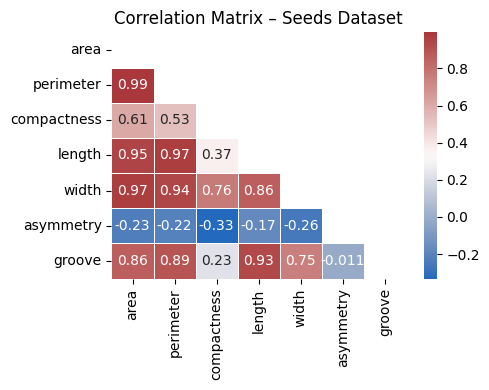

In [23]:
plt.figure(figsize=(5, 4))
R_seeds = df_seeds_feat.corr()
mask = np.triu(np.ones_like(R_seeds, dtype=bool))
seaborn.heatmap(R_seeds, annot=True, mask=mask, cmap='vlag', linewidths=0.5)
plt.title('Correlation Matrix – Seeds Dataset')
plt.tight_layout()
plt.show()

### Step 4：PCA 分析

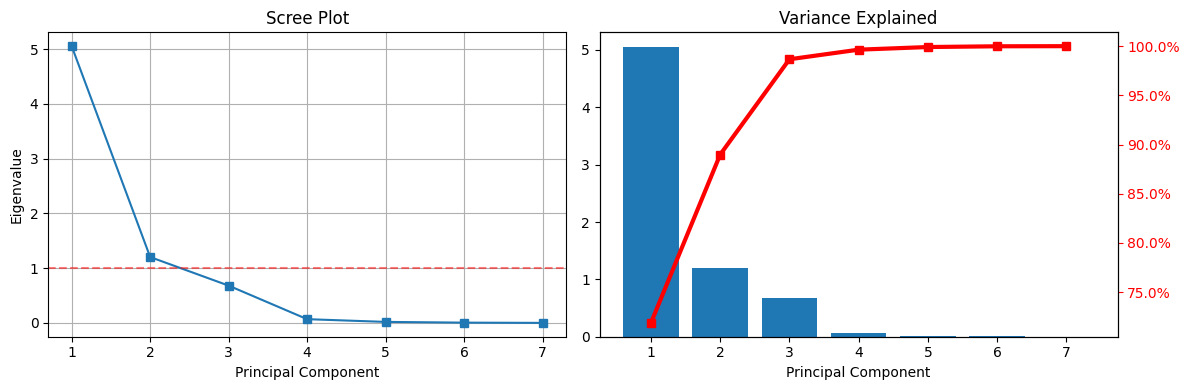

各主成分解釋變異比例： [7.187e-01 1.711e-01 9.690e-02 9.800e-03 2.700e-03 8.000e-04 1.000e-04]


In [24]:
pca_seeds = PCA().fit(df_seeds_scaled)

eigvals_seeds = pca_seeds.explained_variance_

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(1, 1 + len(eigvals_seeds))

ax[0].plot(x, eigvals_seeds, marker='s')
ax[0].axhline(y=1, color='red', linestyle='--', alpha=0.5)
ax[0].set_title('Scree Plot')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Eigenvalue')
ax[0].grid(True)

ax[1].bar(x, eigvals_seeds)
ax2 = ax[1].twinx()
ax2.plot(x, pca_seeds.explained_variance_ratio_.cumsum() * 100,
         marker='s', color='red', lw=3)
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax[1].set_xlabel('Principal Component')
ax[1].set_title('Variance Explained')
plt.tight_layout()
plt.show()

print('各主成分解釋變異比例：', pca_seeds.explained_variance_ratio_.round(4))

### Step 5：前兩個主成分散佈圖（含類別標籤）

這個資料集有真實類別標籤，可以驗證 PCA 是否能有效區分三種小麥品種。

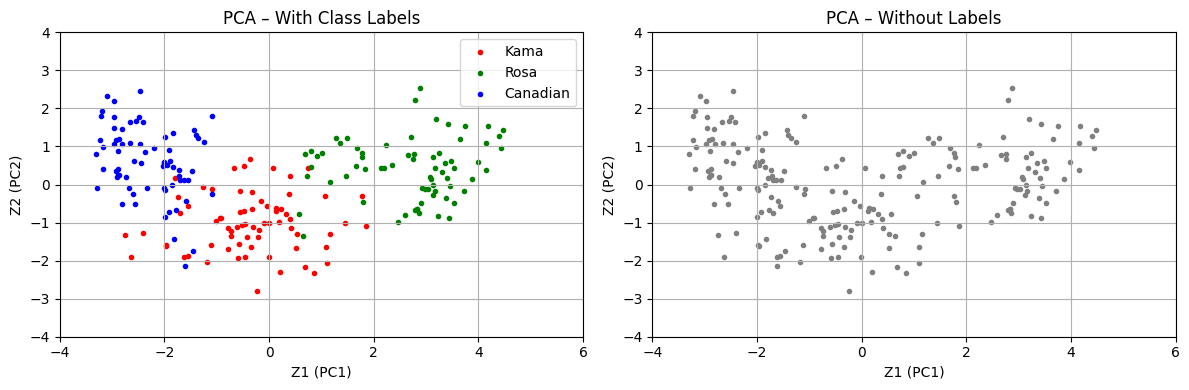

In [25]:
Z_seeds = pca_seeds.transform(df_seeds_scaled)[:, :2]
classes = ['Kama', 'Rosa', 'Canadian']
colors = ['red', 'green', 'blue']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 帶類別標籤
for i in np.arange(1, 4):
    ax[0].scatter(Z_seeds[labels_seeds == i, 0], Z_seeds[labels_seeds == i, 1],
                  marker='.', color=colors[i - 1], label=classes[i - 1])
ax[0].set_xlabel('Z1 (PC1)')
ax[0].set_ylabel('Z2 (PC2)')
ax[0].set_title('PCA – With Class Labels')
ax[0].set_xlim(-4, 6)
ax[0].set_ylim(-4, 4)
ax[0].grid(True)
ax[0].legend()

# 不帶類別標籤
ax[1].scatter(Z_seeds[:, 0], Z_seeds[:, 1], marker='.', color='gray')
ax[1].set_xlabel('Z1 (PC1)')
ax[1].set_ylabel('Z2 (PC2)')
ax[1].set_title('PCA – Without Labels')
ax[1].set_xlim(-4, 6)
ax[1].set_ylim(-4, 4)
ax[1].grid(True)

plt.tight_layout()
plt.show()

### Step 6：主成分負荷量

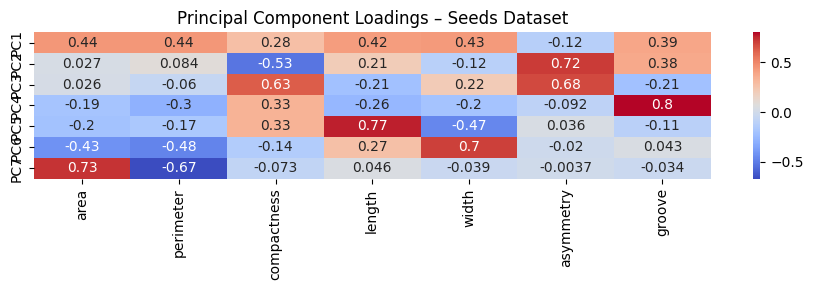

In [26]:
plt.figure(figsize=(9, 3))
seaborn.heatmap(pca_seeds.components_, cmap='coolwarm', annot=True,
                xticklabels=df_seeds_feat.columns,
                yticklabels=[f'PC{i}' for i in range(1, 8)])
plt.title('Principal Component Loadings – Seeds Dataset')
plt.tight_layout()
plt.show()

<font color=orange>**結論（範例 4）：**</font>

> （請根據上方圖表填入你的分析結論）
>
> - PCA 是否能在不知道類別標籤的情況下，自然地分開三種小麥品種？
> - 前幾個主成分足以描述這個資料集？
> - 哪些特徵對第一主成分的貢獻最大？這有什麼意義？

<hr>

## 綜合比較與總結

| 資料集 | 樣本數 | 特徵數 | 建議主成分數 | 前兩個PC累積解釋變異 |
|--------|--------|--------|-------------|--------------------|
| City Quality | 329 | 9 | ? | ? |
| Son Head | 25 | 4 | ? | ? |
| Football Head | 60 | 6 | ? | ? |
| Seeds | 210 | 7 | ? | ? |

**思考問題：**
1. PCA 在哪種情境下最有效？（高相關性 vs 低相關性的特徵）
2. PCA 能否用於分類問題？有何限制？
3. 資料標準化對 PCA 結果的影響為何？什麼情況下可以不標準化？